In [1]:

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

import graphviz
import pyconll
from utils.parser_utils import load_by_sent_id, conllu_to_graphviz
from IPython.display import display_svg


sns.set_theme(style="whitegrid")
so.Plot.config.display["format"] = "svg"
pd.options.mode.chained_assignment = None

ud_data_path = "diaparser/ud_test.conllu"

In [2]:
# Import the data
data = pd.read_csv('results.csv')
data['ellipsis'] = data['ellipsis'] == 1
data.head(3)

,word,ud_test_head,ud_test_deprel,ud_preds_head,ud_preds_deprel,str_test_head,str_test_deprel,str_preds_head,str_preds_deprel,ellipsis,text,sent_id
0,другой,6,amod,6,amod,6,опред,6,опред,False,Другой необычный для системы образования проек...,63_2013Plody_alternativnogo_prosveshcheniya
1,необычный,6,amod,6,amod,6,опред,6,опред,False,Другой необычный для системы образования проек...,63_2013Plody_alternativnogo_prosveshcheniya
2,для,4,case,4,case,2,1-компл,2,1-компл,False,Другой необычный для системы образования проек...,63_2013Plody_alternativnogo_prosveshcheniya


In [3]:
heads = data.drop(columns=['ud_test_deprel', 'ud_preds_deprel', 'str_test_deprel', 'str_preds_deprel'])

deprels = data.drop(columns=['ud_test_head', 'ud_preds_head', 'str_test_head', 'str_preds_head'])
deprels = deprels.rename(columns={'ud_test_deprel': 'ud_test', 'ud_preds_deprel': 'ud_pred', 'str_test_deprel': 'str_test', 'str_preds_deprel': 'str_pred'})

In [4]:
# Create dataframe where ud was wrong but str was correct
mismatches = deprels[(deprels['ud_test'] != deprels['ud_pred']) & (deprels['str_test'] == deprels['str_pred'])]
all = deprels[deprels['str_test'] == deprels['str_pred']]

In [5]:
# Calculate the most frequent mismatches in dependency relations relative to the predcitions
mismatch_count = mismatches.groupby(['ud_pred', 'str_test']).size().reset_index(name='count')
all_count = all.groupby(['ud_pred', 'str_test']).size().reset_index(name='count')

preds_count = pd.merge(mismatch_count, all_count, on=['ud_pred', 'str_test'], suffixes=('_mismatch', '_all'))
preds_count['frequency'] = (preds_count['count_mismatch'] / preds_count['count_all'] * 100).round(decimals=2)
preds_count = preds_count.drop(columns=['count_all']).rename(columns={'count_mismatch': 'count'})

preds_count = preds_count[(preds_count['count'] > 10) & (preds_count['frequency'] > 50)] # count and frequency thresholds
preds_count = preds_count.sort_values(['frequency', 'count'], ascending=[False, False]).reset_index(drop=True)

preds_count['ud_golds'] = preds_count.apply(lambda row: deprels[(deprels['ud_pred'] == row['ud_pred']) & (deprels['str_test'] == row['str_test'])]['ud_test'].value_counts().index[:3].tolist(), axis=1)
preds_count['ud_golds'] = preds_count['ud_golds'].apply(lambda x: ',   '.join(x))
preds_count = preds_count.rename(columns={'str_test': 'str_gold'})

preds_count.head(15)

,ud_pred,str_gold,count,frequency,ud_golds
0,root,предик,15,93.75,"nsubj, csubj, root"
1,nsubj,1-компл,19,86.36,"obj, obl, nsubj"
2,obl:tmod,обст,18,72.00,"obl, obl:tmod, advmod"
3,xcomp,присвяз,22,62.86,"obl, xcomp"


In [6]:
# Calculate the most frequent mismatches in dependency relations relative to the gold standard
mismatch_count = mismatches.groupby(['ud_test', 'str_test']).size().reset_index(name='count')
all_count = all.groupby(['ud_test', 'str_test']).size().reset_index(name='count')

gold_count = pd.merge(mismatch_count, all_count, on=['ud_test', 'str_test'], suffixes=('_mismatch', '_all'))
gold_count['frequency'] = (gold_count['count_mismatch'] / gold_count['count_all'] * 100).round(decimals=2)
gold_count = gold_count.drop(columns=['count_all']).rename(columns={'count_mismatch': 'count'})

gold_count = gold_count[(gold_count['count'] > 20) & (gold_count['frequency'] > 50)] # count and frequency thresholds
gold_count = gold_count.sort_values(['count', 'frequency'], ascending=[False, False]).reset_index(drop=True)
# Add column with three most probable ud_test_deprel standarts (not including predicted) for this ud_preds_deprel and str_test_deprel
gold_count['ud_preds'] = gold_count.apply(lambda row: deprels[(deprels['ud_test'] == row['ud_test']) & (deprels['str_test'] == row['str_test'])]['ud_pred'].value_counts().index[:3].tolist(), axis=1)
gold_count['ud_preds'] = gold_count['ud_preds'].apply(lambda x: ',   '.join(x))
gold_count = gold_count.rename(columns={'ud_test': 'ud_gold', 'str_test': 'str_gold'})
gold_count.head(15)

,ud_gold,str_gold,count,frequency,ud_preds
0,xcomp,присвяз,80,86.02,"obl, xcomp, advmod"
1,case,сравнит,66,100.00,mark
2,acl,1-компл,45,91.84,"obl, acl, nmod"
3,obl:agent,агент,38,100.00,obl
4,obl:tmod,обст,34,82.93,"obl, obl:tmod, parataxis"
5,iobj,обст,25,92.59,"obl, iobj, nsubj"
6,obl:tmod,длительн,25,83.33,"obl, obl:tmod, nummod:gov"
7,mark,огранич,24,96.00,"cc, mark, advmod"
8,appos,примыкат,21,77.78,"parataxis, appos"


In [7]:
# Create dataframe with the most frequent mismatches
top_groups = []
for i in range(9):
    group = gold_count.iloc[i]
    ud_test_deprel = group['ud_gold']
    ud_preds_deprel = group['ud_preds']
    str_test_deprel = group['str_gold']
    top_groups.append(mismatches[(mismatches['ud_test'] == ud_test_deprel) & (mismatches['str_test'] == str_test_deprel)])

#### Связь `присвяз` и ошибка `xcomp -> obl`:
* *Note: Я не уверен, является ли это на самом деле ошибкой, или правильная связь всё таки `xcomp` (в таком случае выходит, что связи `obl` являются ошибкой), или это сложный тип зависимости, который парсер не смог усвоить*
* В случае таких предложений как:
    * Оно оказалось очень дешевым.
    * Бродячий философ оказался душевнобольным.
    * Угрозой стал террор.
* Слова "дешевым", "душевнобольным" и "угрозой" должны были получить идущую от глагола связь `obl`, так как принадлежат к существительным или прилагательным частям речи, но вместо этого при конвертации им присваивается связь клаузного комплимента `xcomp`.

* Пример неправильного присваивания `xcomp` вместо `obl`:
  

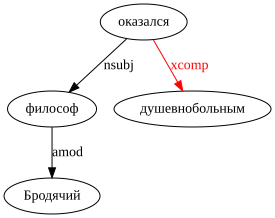

In [8]:
sent = load_by_sent_id(ud_data_path, "227_2018Pontii_Pilat")
dot = conllu_to_graphviz(sent, highlight=('душевнобольным', 'xcomp'))
svg_data = dot.pipe().decode()
dot.render('pics/example_1', format='svg', cleanup=True)
display_svg(svg_data, raw=True)

#### Связь `сравнит` и ошибка `mark -> case`:

* Синтаксическая связь `сравнит` вводит вторую часть сравнительной конструкции и в UD в таких случаях на сравнительный союз должна идти связь `case`, а это не соблюдается и в ходе конвертации связи типа `сравнит` и идущей от неё связи `сравн-союзн` в отношении союза часто присваевается отношение `mark`.

* Пример неправильного присваивания `mark` вместо `case`:

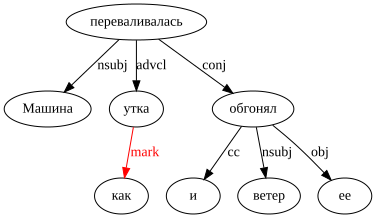

In [14]:
sent = load_by_sent_id(ud_data_path, "177_uppsalaBitov_1")
dot = conllu_to_graphviz(sent, highlight=('как', 'mark'))
svg_data = dot.pipe().decode()
dot.render('pics/example_2', format='svg', cleanup=True)
display_svg(svg_data, raw=True)

#### Группа ошибок неуточнённой связи `obl`:

* Включает в себя случаи, когда было присвоено отношение `obl` в тех случаях, где правильным было бы присвоить его существующее уточнение, специфичное для UD русского языка, например `obl:agent` и `obl:tmod`.
  
* *Note: Отношение `obl:tmod` по какой-то причине не встречается в guidelines для русского от Universal Dependencies.*

* Пример неуточнённой связи `obl` вместо `obl:tmod`:

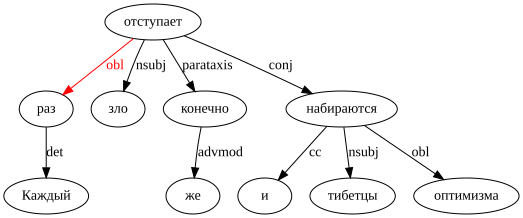

In [25]:
sent = load_by_sent_id(ud_data_path, "61_2013Maski")
dot = conllu_to_graphviz(sent, highlight=('раз', 'obl'))
svg_data = dot.pipe().decode()
dot.render('pics/example_3', format='svg', cleanup=True)
display_svg(svg_data, raw=True)

#### Связь `огранич` и ошибка `cc -> mark`:

* Для распространённой конструкции "то есть", которая служит для введения подчиненной клаузы, а не для соединения двух равноважных клауз (как это происходит у связи `cc`), будет правильным использовать связь `mark`. Исходя из этого, те предложения в которых на союз "то" идёт связь `cc` являются неверно конвертироваными

* Пример неправильной связи `cc` вместо `mark`:

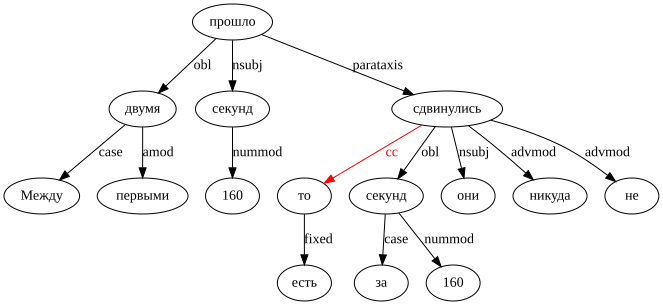

In [79]:
sent = load_by_sent_id(ud_data_path, "134_2011Sverkhkorotkoe_vremya")
dot = conllu_to_graphviz(sent, highlight=('то', 'cc'))
svg_data = dot.pipe().decode()
dot.render('pics/example_4', format='svg', cleanup=True)
display_svg(svg_data, raw=True)

In [ ]:
test = deprels[(deprels['ud_test'] == 'cc') & (deprels['str_test'] == 'огранич')]
test.shape[0]

In [ ]:
# print 'text' for the first five sentences in the first group
for i, row in test[12:].head(4).iterrows():
    print(f"Word: {row['word']}")
    print("Sent id:", row['sent_id'])
    print(f"Text: {row['text']}")
    print(f"UD: {row['ud_pred']} -> {row['ud_test']}")
    print(f"STR: {row['str_pred']} -> {row['str_test']}")
    print()